# Assignment 4: Regularization 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters? **This makes sure that the model isn't overfit because models tend to overfit when the parameter size is bit. Models with large parameters tend to overfit to noise. If the model overfits to training data, then it may not be able to predict as well for other test sets. The intuition to adding a penalty to the model parameters is to keep it simple and small in order to not let extremely large parameters impact the fitting.**
2. How does regularization provide a way of exploring the bias-variance trade-off? \
**When a model is overfit, variance is too high, therefore, when applying regularization, we can make the coefficients shrink and therefore shrink variance. This also means that bias is higher. Because we are forcing the model to be simpler, we are forcing it to become more underfit, to the point where we may not be able to capture the full compexity of the model, increasing bias.**
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems? \
**While they are both regularization methods used to simplify models so that they do not become too complex, LASSO and Ridge regression are used for different fundamental purposes. With LASSO, some coefficients are so simplified they reduce to 0, leaving the other coefficients that are more important to the model in. This makes it so that coefficients are either in or out of the equation entirely and helps with feature selection and choosing the right model. With Ridge, all the coefficients shrunk towards 0, but never removes anything systematically. It is more useful for stability and prediction.**
4. How do we typically scale variables for use in regularized regression? Why?\
**We scale using the z-score method on the numeric variables but not the one-hot encoded ones. This makes our parameters comparable in terms of explanatory power. We need to scale because we compare the coefficients and to compare, they need to be in the same scale.**
5. How is the penalty $\alpha$ typically selected?\
**$\alpha$ is the variable that determines the cost of purchasing. We use k-fold cross validation to compare the possible $\alpha$ and get a mean squared error value. We use the mean of median of the MSE and determine which alpha to use.**
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?\
**No, the penalty term is not evaluated because the penalty is only used for how the model is trained to fit. It should not change across different predictions.**

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 


In [16]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('data/cars_hw.csv')
df["Age"] = 2026-df["Make_Year"]
features = df[["Mileage_Run", "Age"]]
poly = PolynomialFeatures(degree = 3, include_bias = False)
X_poly = poly.fit_transform(features)
X_scaled = StandardScaler().fit_transform(X_poly)
df.head()


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?\
**The sign for interaction between 'mileage run' and 'age' is -1.67e+06, which is negative meaning that the combined effect decreases the price of the car.**

In [20]:
from sklearn.linear_model import LinearRegression
y = df["Price"]
model = LinearRegression()
model.fit(X_scaled, y)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})
coef_df

,Feature,Coefficient
0,Mileage_Run,9.117748e+05
1,Age,-2.481722e+05
2,Mileage_Run^2,-2.072926e+05
3,Mileage_Run Age,-1.671212e+06
4,Age^2,3.505507e+05
5,Mileage_Run^3,-6.514490e+04
6,Mileage_Run^2 Age,3.388195e+05
7,Mileage_Run Age^2,7.167816e+05
8,Age^3,-2.100379e+05


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [34]:
from sklearn.linear_model import LassoCV, Lasso
alpha_grid = np.logspace(1, 3, 20)
model = LassoCV(cv=20, alphas=alpha_grid, random_state=100)
model = model.fit(X_scaled, y)

alpha_star = model.alpha_
alpha_star

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(69.51927961775606)

4. Plot the cross-validated MSE by $\alpha$.

Optimal cost hyperparameter: 69.51927961775606


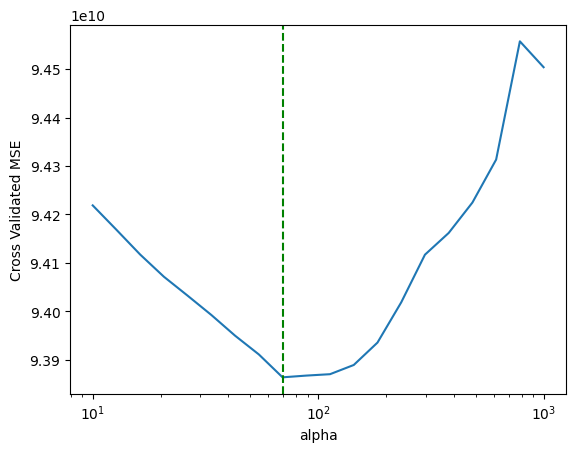

In [37]:
sns.lineplot(x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

5. Plot the coefficient paths by $\alpha$.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

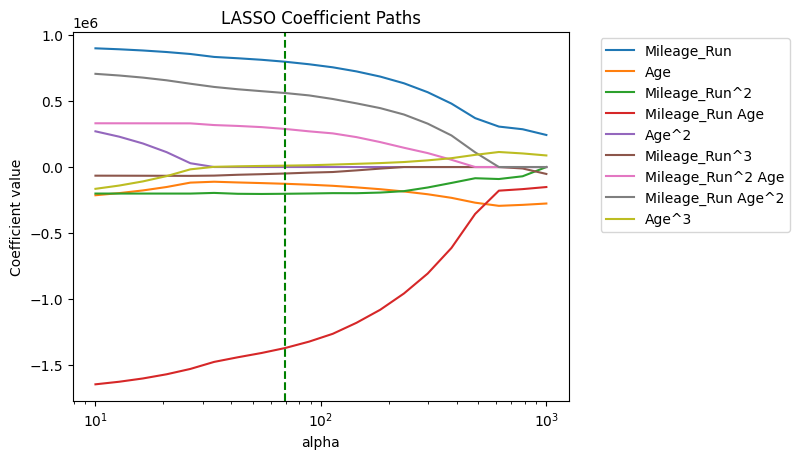

In [39]:
poly_names = poly.get_feature_names_out()
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X_scaled,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i]) 
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?\
**The features that are selected are ['Mileage_Run', 'Age', 'Mileage_Run Age', 'Mileage_Run^3', 'Age^3']. The proportion that was set to 0 was 44%.**

In [51]:
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
coefs = model.coef_
selected_features = feature_names[coefs != 0]
print(selected_features)
prop_zero = np.mean(coefs == 0)
print(f"Proportion equal to 0: {prop_zero}")
coefs.mean()

['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']
Proportion equal to 0: 0.4444444444444444


np.float64(-16639.981331596693)

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? **From the linear regression, we can see that the coefficient is -1,671,212 while the coeficcient for LASSO is -16639.981331596693. We can see that the sign is still negative. In addition, we can see that the absolute value of the lienar regression coefficient is till bigger than the LASSO. This means regularization worked because LASSO shrinks coefficients.**

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [ ]:
df2 = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

features2 = df2[["age", "ejection_fraction", "serum_creatinine"]]
poly2 = PolynomialFeatures(degree = 3, include_bias = False)
X_poly2 = poly2.fit_transform(features2)
X_scaled2 = StandardScaler().fit_transform(X_poly2)
f_2 = poly2.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
X_scaled2 = pd.DataFrame(X_scaled2, columns = f_2)

features3 = df2[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
poly3 = PolynomialFeatures(degree = 3, include_bias = False, interaction_only = True)
X_poly3 = poly3.fit_transform(features3)
f_3 = poly3.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
X_poly3 = pd.DataFrame(X_poly3, columns = f_3)
# no scaling bc they are categorical

X_concat = pd.concat([X_scaled2,X_poly3], axis = 1)
X_concat


,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking,anaemia diabetes high_blood_pressure,anaemia diabetes smoking,anaemia high_blood_pressure smoking,diabetes high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.007077,-0.284552,0.001468,0.035053,-0.258596,-0.146835,-0.214284,-0.220393,-0.087411,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
295,-0.491279,-0.007077,-0.187726,-0.539187,-0.267742,-0.289270,-0.146835,-0.141229,-0.192224,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
296,-1.333392,1.854958,-0.575031,-1.199328,0.426637,-0.707543,2.022144,-0.095088,-0.290202,-1.058973,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
297,-1.333392,-0.007077,0.005926,-1.199328,-0.700305,-0.331097,-0.146835,0.004882,-0.128539,-1.058973,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?\
**Yes, there are sign patterns that are kind of counterintuitive. One of them is that age by itself has a positive coefficient but age^2 has a negative coefficient. By age^3, however, it was back to postive. With one power, the model remains linear in its predictions, but with more higher-ordered powers, the prediction rests on the combined effect of all the terms. This is good because the addition of the higher powered terms add non-linearity to the model, making it easier to fit.**

In [81]:
Y2 = df2["DEATH_EVENT"]
model2 = LinearRegression()
model2 = model2.fit(X_concat, Y2)

feature_names2 = X_concat.columns
coef_df2 = pd.DataFrame({
    "Feature": feature_names2,
    "Coefficient": model2.coef_
})
coef_df2

,Feature,Coefficient
0,age,1.549928
1,ejection_fraction,-2.025371
2,serum_creatinine,-0.739027
3,age^2,-3.547991
4,age ejection_fraction,-0.861860
5,age serum_creatinine,1.680570
6,ejection_fraction^2,3.317931
7,ejection_fraction serum_creatinine,2.604767
8,serum_creatinine^2,-2.703084
9,age^3,1.889040


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

In [86]:
alpha_grid3 = np.logspace(-5, 5, 30)
model3 = LassoCV(cv=20, alphas=alpha_grid3, random_state=100)
model3 = model3.fit(X_concat, Y2)

alpha_star3 = model3.alpha_
alpha_star3

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.010e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.382e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(0.005736152510448681)

4. Plot the cross-validated MSE by $\alpha$.

Optimal cost hyperparameter: 0.005736152510448681


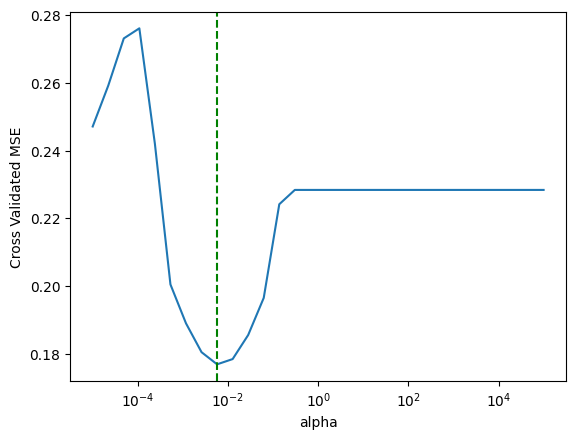

In [88]:
sns.lineplot(x=model3.alphas_, y= np.mean(model3.mse_path_,axis=1) )
plt.axvline(x=alpha_star3, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star3}')

5. Plot the coefficient paths by $\alpha$.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.881e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.637e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

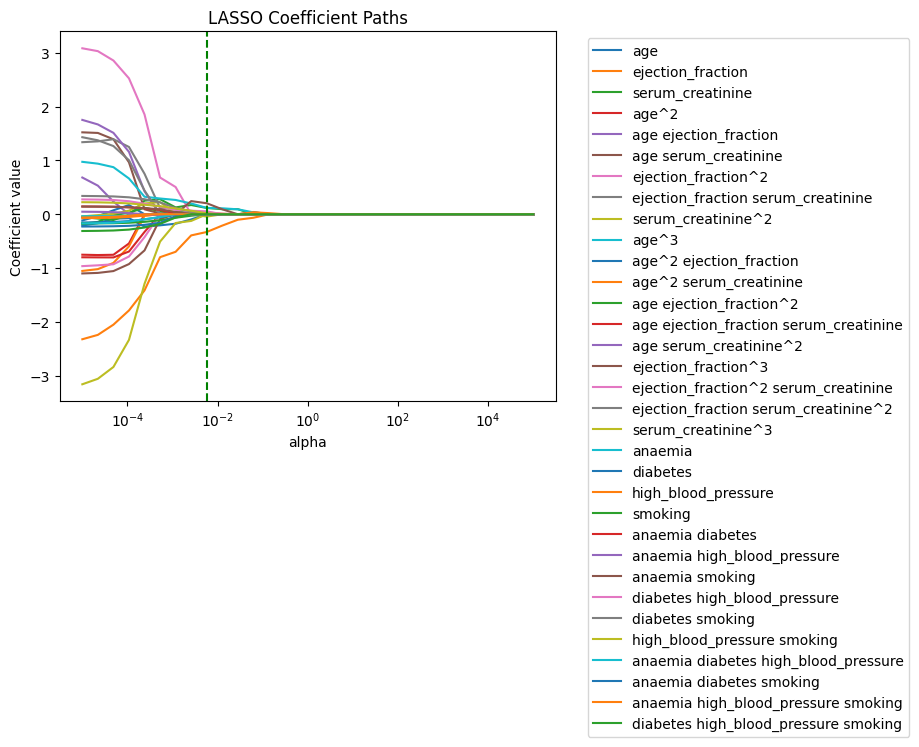

In [95]:
poly_names3 = X_concat.columns
coefs3 = []
for alpha3 in alpha_grid3:
    model3 = Lasso(alpha=alpha3, max_iter=10_000)
    model3 = model3.fit(X_concat,Y2)
    coefs3.append(model3.coef_)
coefs3 = np.array(coefs3)

plt.figure()
for i in range(coefs3.shape[1]):
    plt.plot(alpha_grid3, coefs3[:, i], label=poly_names3[i]) 
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star3, color='green', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.
**The features that were actually selected were ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2, serum_creatinine', 'serum_creatinine^3', 'anaemia','diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure','diabetes smoking', 'high_blood_pressure smoking']. The proportion that was set to 0 is about 63%. The coefficient from the linear regression for the continuous variables is -1.584620, while the coefficient from LASSO is 0.00615760219039735. While I think some increased, the overall average was a decrease. Some zeroes carry a negative sign now, serum creatinine also changed signs. The amount of sign changes might be LASSO correcting and making the model more stable because the linear regression model carried too many parameters, had too high of a variance, and was probably overfitting. In contrast, the LASSO version lowered the variance, producing more stable signs overall.**

In [114]:
alpha_grid3 = np.logspace(-5, 5, 30)
lasso_cv_model3 = LassoCV(cv=20, alphas=alpha_grid3, random_state=100, max_iter=10000)
lasso_cv_model3.fit(X_concat, Y2)

alpha_star3 = lasso_cv_model3.alpha_
print(alpha_star3)

feature_names3 = X_concat.columns
coefs3 = lasso_cv_model3.coef_
selected_features3 = feature_names3[coefs3 != 0]
print(selected_features3)


prop_zero3 = np.mean(coefs3 == 0)
print(f"Proportion equal to 0: {prop_zero3}")
print(lasso_cv_model3.coef_)
print(coef_df2)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.661e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.488e+00, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

0.005736152510448681
Index(['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3',
       'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia',
       'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure',
       'diabetes smoking', 'high_blood_pressure smoking'],
      dtype='object')
Proportion equal to 0: 0.6363636363636364
[-0.         -0.32965588  0.11687513  0.         -0.          0.
  0.          0.         -0.          0.1179918   0.          0.
  0.          0.         -0.          0.20482164  0.0328011  -0.
 -0.04326608  0.01417834  0.0006065   0.01360816 -0.          0.
  0.          0.          0.05396847  0.00346643  0.01780528  0.
  0.          0.          0.        ]
                                   Feature  Coefficient
0                                      age     1.549928
1                        ejection_fraction    -2.025371
2                         serum_creatinine    -0.739027
3                                  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.159e+01, tolerance: 6.322e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.702e-01, tolerance: 6.322e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

**ridge = np.mean((y_actual - (y_pred))**2) + alpha * (b1**2)**

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

**$b_0$ = 0**\
**$b_1$ = np.sum(x_actual * y_actual) / (np.sum(x_actual**2) + len(x_actual) * alpha)**

3. How does increasing $\alpha$ change the slope coefficient?

**Increasing the alpha decreases the slop coefficient because the derivative with respect to $b_1$ has alpha in the denominator, which means that as alpha increases, the entire function decreases.**

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**With LASSO, |b_1| is not differentiable at zero which means that we cannot take the derivative. We can split into cases instead. When b_1 is greater than or less than 0. It is optimal to set b_1 to 0 when the correlation term is too small to overcome the penalty.**